In [1]:
# Cell 1 — Setup
"""
02_train.ipynb
==============
Train TGNN-Solv with 3-phase curriculum learning.
Assumes 01_prepare_data.ipynb has been run.
"""

import sys
sys.path.insert(0, "../src")

import torch
import pandas as pd

from tgnn_solv.config import TGNNSolvConfig
from tgnn_solv.model import TGNNSolv
from tgnn_solv.trainer import TGNNSolvTrainer
from tgnn_solv.inference import save_model
from tgnn_solv.data import make_loaders, PROCESSED_DIR

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
# Cell 2 — Load processed data
train_df = pd.read_csv(PROCESSED_DIR / "train_solute.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val_solute.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test_solute.csv")

print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")

Train: 96,157
Val:   12,054
Test:  11,986


In [3]:
# Cell 3 — Configuration
cfg = TGNNSolvConfig(
    hidden_dim=128,
    n_gnn_layers=4,
    n_cross_attn_layers=1,
    n_attn_heads=4,
    pair_dim=256,
    dropout=0.35,               # 0.2 → 0.35
    n_iter_train=3,
    n_iter_eval=10,
    use_implicit_diff=True,
    batch_size=128,
    lr_phase1=3e-4,
    lr_phase2=3e-4,
    lr_phase3=3e-5,
    epochs_phase1=2,
    epochs_phase2=5,
    epochs_phase3=1,
    warmup_epochs=5,
    patience=40,
    S_g=5000.0,
    tau_clamp=15.0
)

print(f"Config: hidden={cfg.hidden_dim}, layers={cfg.n_gnn_layers}")

Config: hidden=128, layers=4


In [4]:
# Cell 4 — Build model
model = TGNNSolv(cfg=cfg).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
physics = sum(p.numel() for p in model.sle_solver.parameters())

print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Physics params:   {physics} (should be 0)")

Total params:     3,426,370
Trainable params: 3,426,370
Physics params:   0 (should be 0)


In [5]:
# Cell 5 — DataLoaders
train_loader, val_loader, test_loader = make_loaders(
    train_df, val_df, test_df,
    batch_size=cfg.batch_size,
)

  Dataset: 11,986 valid (0 dropped, 2243 cached graphs)
  Train: 96,157 samples, 751 batches
  Val: 12,054 samples, 95 batches
  Test: 11,986 samples, 94 batches


In [ ]:
# Cell 5b — Pretrain GNN (Stage 0)
from tgnn_solv.pretrain import Pretrainer, download_zinc250k

# Download or collect SMILES
smiles_for_pretrain = download_zinc250k()

# Pretrain GNN encoder + readout
pretrainer = Pretrainer(model.gnn, model.readout, cfg, DEVICE)
pretrain_history = pretrainer.pretrain(
    smiles_for_pretrain,
    n_epochs=2,          # 30 epochs
    batch_size=128,
    lr=3e-4,
    mask_ratio=0.15,
    mask_hops=2,
    bond_mask_ratio=0.15,
    aug_node_mask_ratio=0.15,
    aug_edge_mask_ratio=0.15,
    bond_loss_weight=0.5,
    contrastive_weight=0.5,
    contrastive_temp=0.1,
)

# Visualize pretraining loss
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pretrain_history["atom"], label="Masked subgraph", color="steelblue")
ax.plot(pretrain_history["bond"], label="Bond pred", color="slateblue")
ax.plot(pretrain_history["prop"], label="Property pred", color="coral")
ax.plot(pretrain_history["contrastive"], label="Contrastive", color="seagreen")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Stage 0: GNN Pretraining")
ax.legend()
plt.tight_layout()
plt.show()

print("GNN pretrained. Proceeding to curriculum training...")

  PretrainDataset: 249,455 molecules


In [6]:
# Cell 6 — Forward pass smoke test
model.eval()
for sol_b, slv_b, tgt in train_loader:
    sol_b = sol_b.to(DEVICE)
    slv_b = slv_b.to(DEVICE)
    T = tgt["T"].to(DEVICE)
    with torch.no_grad():
        out = model(sol_b, slv_b, T)
    print("Forward pass OK")
    print(f"  ln(x₂) shape: {out['ln_x2'].shape}")
    print(f"  T_m range: [{out['fusion_params']['T_m'].min():.0f}, "
          f"{out['fusion_params']['T_m'].max():.0f}]")
    print(f"  Gate: {out['gate'].item():.4f}")
    break

Forward pass OK
  ln(x₂) shape: torch.Size([128])
  T_m range: [390, 405]
  Gate: 0.9004


In [7]:
# Cell 7 — Train
trainer = TGNNSolvTrainer(model, cfg)
trainer.train_full(train_loader, val_loader)

  Epoch   0/1: train=0.8293, val=1.2191, MAE=1.469, R²=0.396, gate=0.652 [direct_reg=1.447, tau_reg=1.266, direct_nll=0.911]

Restored best model (val MAE = 1.4688)


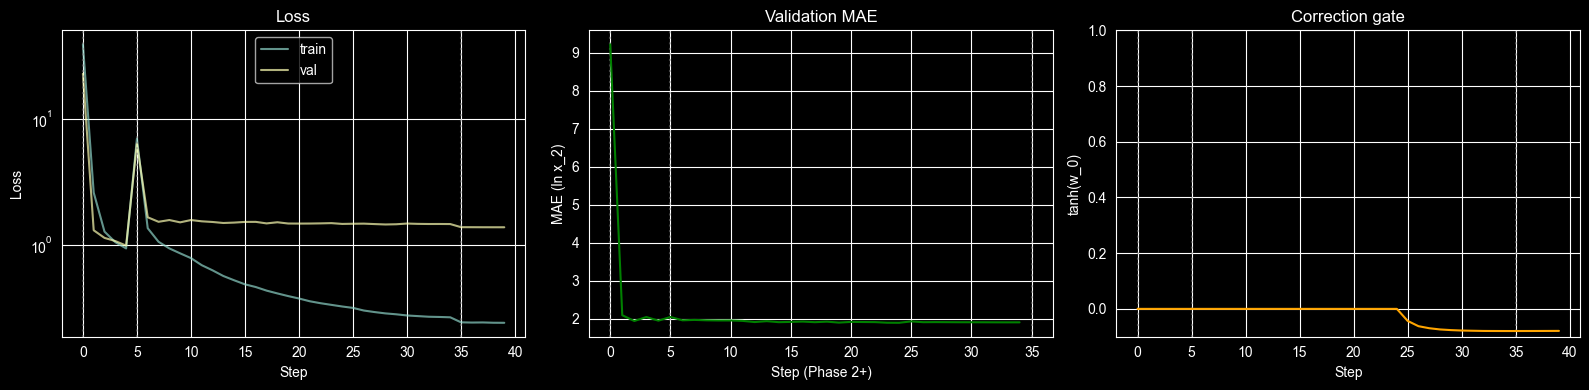

In [12]:
# Cell 8 — Training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(trainer.history["train_loss"], label="train", alpha=0.7)
axes[0].plot(trainer.history["val_loss"], label="val", alpha=0.7)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Loss")

# Phase boundaries
phases = trainer.history["phase"]
for p in [1, 2, 3]:
    starts = [i for i, x in enumerate(phases) if x == p]
    if starts:
        for ax in axes:
            ax.axvline(starts[0], color="gray", ls=":", alpha=0.5)

# MAE
if trainer.history["val_mae"]:
    axes[1].plot(trainer.history["val_mae"], color="green")
    axes[1].set_xlabel("Step (Phase 2+)")
    axes[1].set_ylabel("MAE (ln x_2)")
    axes[1].set_title("Validation MAE")

# Gate
axes[2].plot(
    [torch.tanh(torch.tensor(g)).item() for g in trainer.history["gate"]],
    color="orange",
)
axes[2].set_xlabel("Step")
axes[2].set_ylabel("tanh(w_0)")
axes[2].set_title("Correction gate")
axes[2].set_ylim(-0.1, 1.0)

plt.tight_layout()
plt.savefig("../checkpoints/training_curves.png", dpi=150)
plt.show()

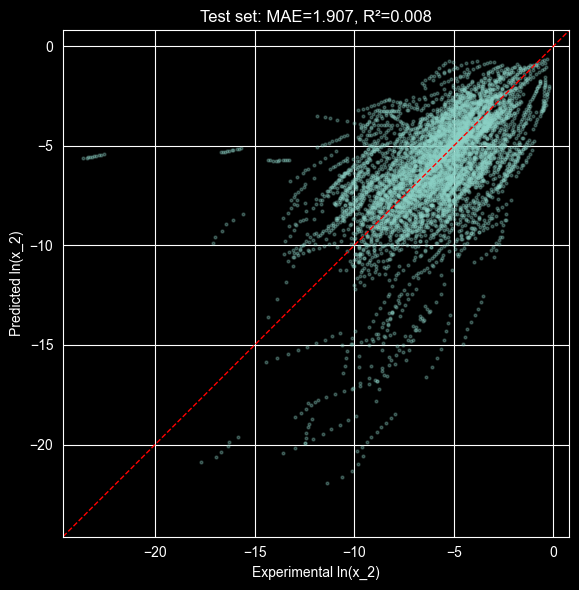

In [10]:
# Cell 9 — Evaluate on test set
from tgnn_solv.loss import TGNNSolvLoss

model.eval()
loss_fn = TGNNSolvLoss(cfg)
all_pred, all_true = [], []

with torch.no_grad():
    for sol_b, slv_b, tgt in test_loader:
        sol_b = sol_b.to(DEVICE)
        slv_b = slv_b.to(DEVICE)
        T = tgt["T"].to(DEVICE)
        mask = tgt["has_solubility"].to(DEVICE)

        out = model(sol_b, slv_b, T)
        if mask.any():
            all_pred.append(out["ln_x2"][mask].cpu())
            all_true.append(tgt["ln_x2"][mask].cpu())

pred = torch.cat(all_pred)
true = torch.cat(all_true)

mae = (pred - true).abs().mean().item()
rmse = (pred - true).pow(2).mean().sqrt().item()
r2_num = (pred - true).pow(2).sum()
r2_den = (true - true.mean()).pow(2).sum()
r2 = 1.0 - (r2_num / (r2_den + 1e-8)).item()

print(f"Test set results (n={len(pred):,}):")
print(f"  MAE  = {mae:.3f} ln-units")
print(f"  RMSE = {rmse:.3f} ln-units")
print(f"  R²   = {r2:.4f}")

# Parity plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true.numpy(), pred.numpy(), s=4, alpha=0.3)
lims = [min(true.min(), pred.min()) - 1, max(true.max(), pred.max()) + 1]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Experimental ln(x_2)")
ax.set_ylabel("Predicted ln(x_2)")
ax.set_title(f"Test set: MAE={mae:.3f}, R²={r2:.3f}")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("../checkpoints/parity_plot.png", dpi=150)
plt.show()

In [11]:
# Cell 10 — Save model
save_model(
    model, cfg,
    "../checkpoints/tgnn_solv_trained.pt",
    metadata={
        "test_mae": mae,
        "test_rmse": rmse,
        "test_r2": r2,
        "n_train": len(train_df),
        "n_test": len(test_df),
    },
)

Model saved to ../checkpoints/tgnn_solv_trained.pt
